# ch212 — Gradient Descent

**Part VII: Calculus**

---

## 1. The Algorithm

Gradient descent minimizes a function f(w) by iteratively stepping in the direction of the negative gradient:

$$w_{t+1} = w_t - \eta \nabla f(w_t)$$

where η (eta) is the **learning rate** — a hyperparameter controlling step size.

The negative gradient *(ch209 — Gradient Intuition)* points toward steepest decrease. Each step reduces f (for small enough η). Repeat until convergence.

This is not just an ML trick — it is a general optimization algorithm applicable to any differentiable scalar function.

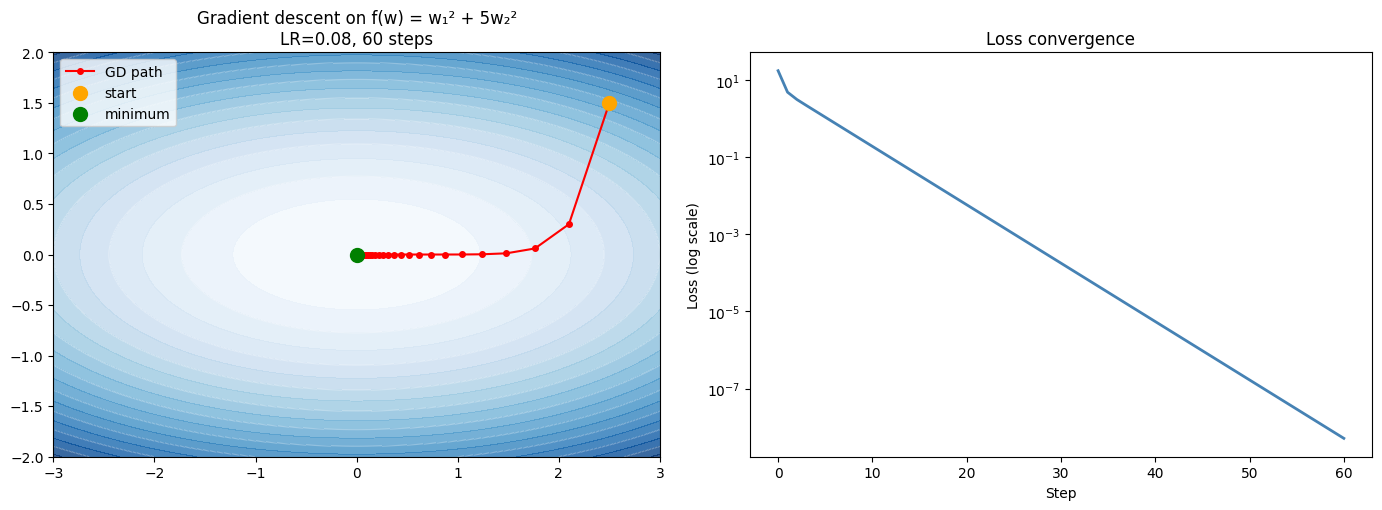

Initial loss: 17.5000
Final loss:   5.12e-09
Converged to: [7.15644227e-05 1.72938226e-42]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(f, grad_f, w0, lr, n_steps, tol=1e-9):
    """
    Run gradient descent from w0.
    Returns history of (w, f(w)) tuples.
    """
    w = np.array(w0, dtype=float)
    history = [(w.copy(), f(w))]
    for _ in range(n_steps):
        g = grad_f(w)
        w = w - lr * g
        history.append((w.copy(), f(w)))
        if np.linalg.norm(g) < tol:
            break
    return history

# Quadratic bowl: f(w1,w2) = w1^2 + 5*w2^2
f     = lambda w: w[0]**2 + 5*w[1]**2
grad_f = lambda w: np.array([2*w[0], 10*w[1]])

w0 = np.array([2.5, 1.5])
hist = gradient_descent(f, grad_f, w0, lr=0.08, n_steps=60)

path = np.array([h[0] for h in hist])
losses = [h[1] for h in hist]

# Contour + path
w1 = np.linspace(-3, 3, 200)
w2 = np.linspace(-2, 2, 200)
W1, W2 = np.meshgrid(w1, w2)
Z = W1**2 + 5*W2**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cs = axes[0].contourf(W1, W2, Z, levels=25, cmap='Blues', alpha=0.8)
axes[0].contour(W1, W2, Z, levels=10, colors='white', alpha=0.4, linewidths=0.8)
axes[0].plot(path[:, 0], path[:, 1], 'o-', color='red', markersize=4, linewidth=1.5, label='GD path')
axes[0].scatter(*w0, color='orange', s=100, zorder=8, label='start')
axes[0].scatter(0, 0, color='green', s=100, zorder=8, label='minimum')
axes[0].set_title(f'Gradient descent on f(w) = w₁² + 5w₂²\nLR={0.08}, {len(hist)-1} steps')
axes[0].legend(); axes[0].set_aspect('equal')

axes[1].semilogy(losses, color='steelblue', linewidth=2)
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Loss convergence')

plt.tight_layout()
plt.show()

print(f'Initial loss: {losses[0]:.4f}')
print(f'Final loss:   {losses[-1]:.2e}')
print(f'Converged to: {path[-1]}')


## 2. Learning Rate Effects

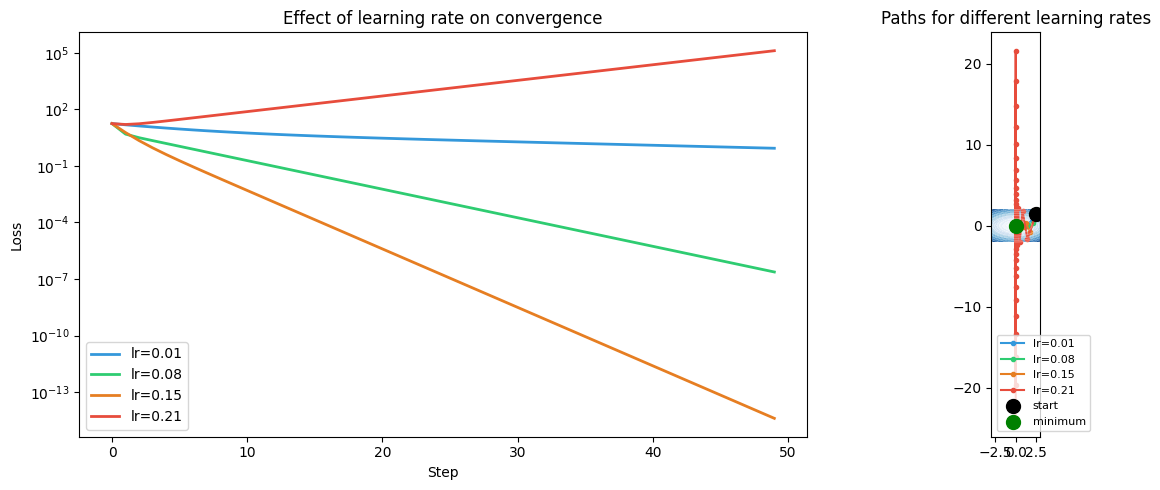

Observations:
  Too small lr → slow convergence
  Too large lr → oscillation or divergence
  Optimal lr depends on curvature of the loss surface (Hessian eigenvalues, ch217)


In [2]:
w0 = np.array([2.5, 1.5])
lrs = [0.01, 0.08, 0.15, 0.21]
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr, color in zip(lrs, colors):
    try:
        hist = gradient_descent(f, grad_f, w0, lr=lr, n_steps=100)
        losses = [h[1] for h in hist]
        path = np.array([h[0] for h in hist])
        axes[0].plot(losses[:50], color=color, linewidth=2, label=f'lr={lr}')
        axes[1].plot(path[:30, 0], path[:30, 1], 'o-', color=color,
                     markersize=3, linewidth=1.5, label=f'lr={lr}')
    except Exception as e:
        print(f'lr={lr} diverged: {e}')

axes[0].semilogy()
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].set_title('Effect of learning rate on convergence')
axes[0].legend()

cs = axes[1].contourf(W1, W2, Z, levels=20, cmap='Blues', alpha=0.6)
axes[1].contour(W1, W2, Z, levels=8, colors='white', alpha=0.3, linewidths=0.8)
axes[1].scatter(*w0, color='black', s=100, zorder=9, label='start')
axes[1].scatter(0, 0, color='green', s=100, zorder=9, label='minimum')
axes[1].set_title('Paths for different learning rates')
axes[1].legend(fontsize=8); axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print('Observations:')
print('  Too small lr → slow convergence')
print('  Too large lr → oscillation or divergence')
print('  Optimal lr depends on curvature of the loss surface (Hessian eigenvalues, ch217)')


## 3. Stochastic Gradient Descent (SGD)

In practice, computing the gradient over the full dataset (batch gradient descent) is expensive. **Stochastic gradient descent** uses a mini-batch — a random subset of data — to estimate the gradient. The estimate is noisy but cheap.

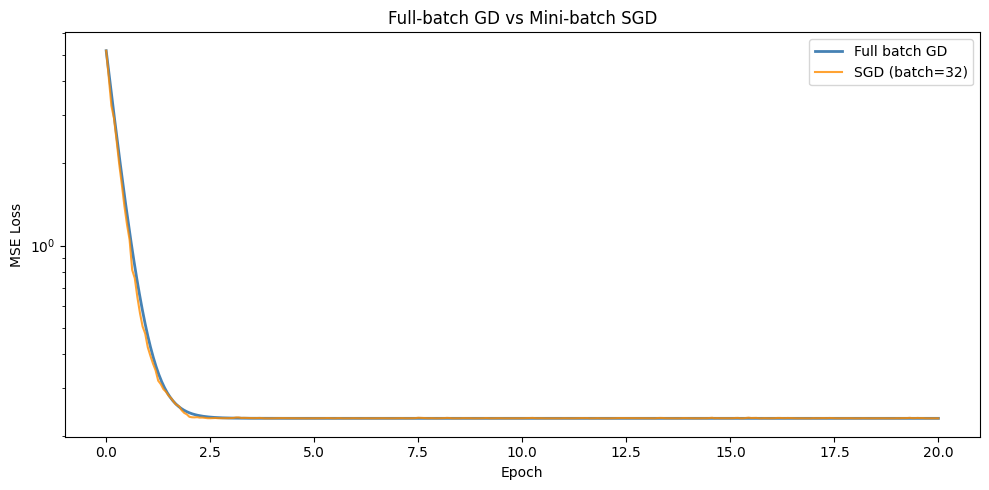

Batch GD final weights:   [ 2.03123619 -0.99509055]
SGD final weights:        [ 2.03380553 -1.00017387]
True weights:             [ 2. -1.]


In [3]:
np.random.seed(0)
N, D = 500, 2
X_full = np.random.randn(N, D)
w_true = np.array([2.0, -1.0])
y_full = X_full @ w_true + 0.5 * np.random.randn(N)

def mse_loss(w, X, y):
    return np.mean((X @ w - y)**2)

def mse_grad(w, X, y):
    residuals = X @ w - y
    return (2/len(y)) * X.T @ residuals

w0 = np.zeros(D)
lr = 0.05
n_epochs = 20
batch_size = 32

# Full batch GD
w_bgd = w0.copy()
losses_bgd = [mse_loss(w_bgd, X_full, y_full)]
for epoch in range(n_epochs * (N // batch_size)):
    g = mse_grad(w_bgd, X_full, y_full)
    w_bgd = w_bgd - lr * g
    losses_bgd.append(mse_loss(w_bgd, X_full, y_full))

# Mini-batch SGD
w_sgd = w0.copy()
losses_sgd = [mse_loss(w_sgd, X_full, y_full)]
indices = np.arange(N)
for epoch in range(n_epochs):
    np.random.shuffle(indices)
    for i in range(0, N, batch_size):
        batch = indices[i:i+batch_size]
        X_b, y_b = X_full[batch], y_full[batch]
        g = mse_grad(w_sgd, X_b, y_b)
        w_sgd = w_sgd - lr * g
        losses_sgd.append(mse_loss(w_sgd, X_full, y_full))

fig, ax = plt.subplots(figsize=(10, 5))
steps_bgd = np.linspace(0, n_epochs, len(losses_bgd))
steps_sgd = np.linspace(0, n_epochs, len(losses_sgd))
ax.semilogy(steps_bgd, losses_bgd, color='steelblue', linewidth=2, label='Full batch GD')
ax.semilogy(steps_sgd, losses_sgd, color='darkorange', linewidth=1.5, alpha=0.8, label=f'SGD (batch={batch_size})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Full-batch GD vs Mini-batch SGD')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Batch GD final weights:   {w_bgd}')
print(f'SGD final weights:        {w_sgd}')
print(f'True weights:             {w_true}')


## 4. Summary

- Gradient descent: wₜ₊₁ = wₜ - η∇f(wₜ)
- Learning rate η controls step size — too large oscillates, too small is slow
- Convergence guaranteed for convex f with sufficiently small η
- Mini-batch SGD: noisy gradient estimate, but much cheaper per step
- The shape of the loss landscape (curvature) determines difficulty of optimization

---

## 5. Forward References

The difficulty of gradient descent on elongated loss surfaces motivates second-order methods discussed via the Hessian in ch217 — Second Derivatives. The optimization landscape with multiple minima and saddle points is ch213 — Optimization Landscapes and ch214 — Saddle Points. The full gradient-based learning algorithm connecting gradient descent to the chain rule is ch227 — Gradient-Based Learning.